## Worksheet4_AyushNeupane

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

np.random.seed(42)

## Part 1: Linear Regression


### Question 1: Simple Linear Regression

1.  **Generate a synthetic dataset:**
    *   Create 100 data points for a variable `X` uniformly distributed between 0 and 10.
    *   Create a variable `y` using the equation $y = 2X + 5 + \epsilon$, where $\epsilon$ is Gaussian noise with a mean of 0 and a standard deviation of 2.


In [3]:
# Generate synthetic dataset
X = np.random.uniform(0, 10, 100)
epsilon = np.random.normal(0, 2, 100)
y = 2 * X + 5 + epsilon

# Create a DataFrame
df_simple = pd.DataFrame({'X': X, 'y': y})
display(df_simple.head())

,X,y
0,3.745401,12.664897
1,9.507143,23.416271
2,7.319939,19.823400
3,5.986585,12.998032
4,1.560186,7.681029


2.  **Visualize the data:** Create a scatter plot of `X` vs `y`.


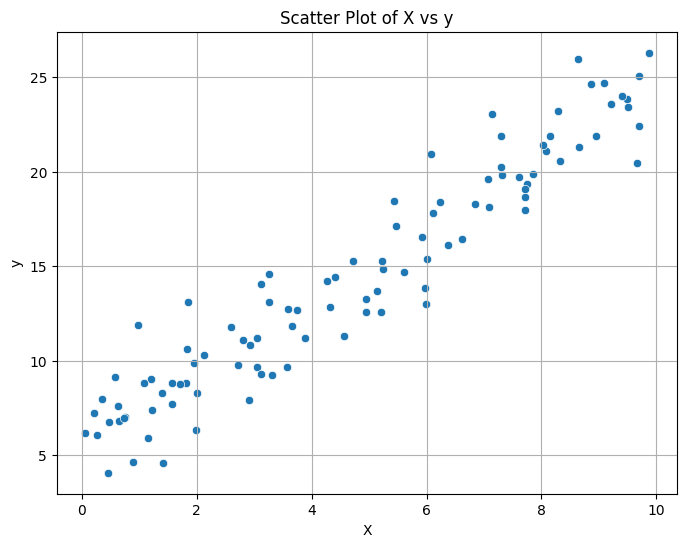

In [4]:
# Visualize the data
plt.figure(figsize=(8, 6))
sns.scatterplot(x='X', y='y', data=df_simple)
plt.title('Scatter Plot of X vs y')
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True)
plt.show()

3.  **Implement Simple Linear Regression from scratch:**
    *   Write a function to calculate the coefficients (slope $m$ and intercept $b$) using the ordinary least squares (OLS) method.
    *   Recall the formulas:
        $$m = \frac{\sum_{i=1}^{n} (X_i - \bar{X})(y_i - \bar{y})}{\sum_{i=1}^{n} (X_i - \bar{X})^2}$$
        $$b = \bar{y} - m\bar{X}$$


In [5]:
# Implement Simple Linear Regression from scratch
def simple_linear_regression(X, y):
    n = len(X)
    mean_X = np.mean(X)
    mean_y = np.mean(y)

    numerator = np.sum((X - mean_X) * (y - mean_y))
    denominator = np.sum((X - mean_X)**2)

    if denominator == 0:
        return 0, mean_y  # Handle case where X values are all the same

    m = numerator / denominator
    b = mean_y - m * mean_X

    return m, b

# Calculate coefficients
m, b = simple_linear_regression(df_simple['X'], df_simple['y'])
print(f"Calculated Slope (m): {m:.4f}")
print(f"Calculated Intercept (b): {b:.4f}")

Calculated Slope (m): 1.9080
Calculated Intercept (b): 5.4302


4.  **Plot the regression line:** Overlay the calculated regression line on the scatter plot.


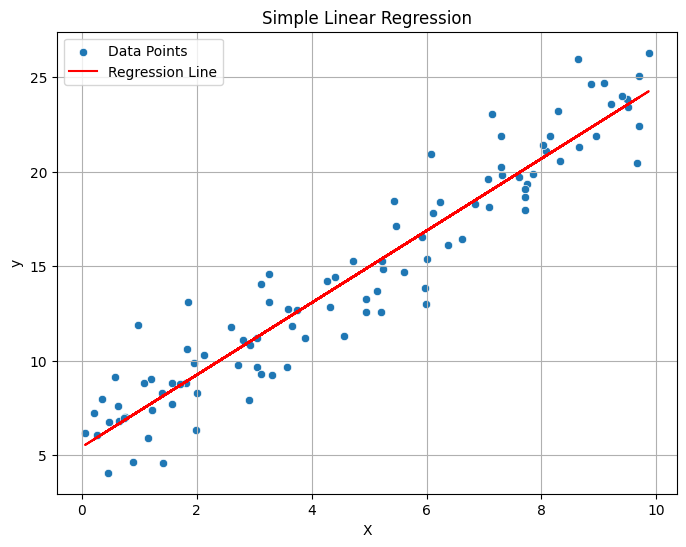

In [6]:
# Plot the regression line
plt.figure(figsize=(8, 6))
sns.scatterplot(x='X', y='y', data=df_simple, label='Data Points')
plt.plot(df_simple['X'], m * df_simple['X'] + b, color='red', label='Regression Line')
plt.title('Simple Linear Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()

5.  **Calculate R-squared (R2) from scratch:**
    *   Implement a function to compute the R2 score, which measures how well the model fits the data.
    *   Recall the formula:
        $$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$
        where $\hat{y}_i$ are the predicted values.


In [7]:
# Calculate R-squared from scratch
def calculate_r_squared(y_true, y_pred):
    ss_total = np.sum((y_true - np.mean(y_true))**2)
    ss_residual = np.sum((y_true - y_pred)**2)

    if ss_total == 0:
        return 1.0  # R-squared is 1 if all true values are the same

    r_squared = 1 - (ss_residual / ss_total)
    return r_squared

# Make predictions
y_pred = m * df_simple['X'] + b

# Calculate R-squared
r2 = calculate_r_squared(df_simple['y'], y_pred)
print(f"R-squared: {r2:.4f}")

R-squared: 0.9081


### Question 2: Multiple Linear Regression with Scikit-learn

1.  **Generate a synthetic dataset with multiple features:**
    *   Create 100 data points for two independent variables `X1` and `X2` uniformly distributed between 0 and 10.
    *   Create a dependent variable `y` using the equation $y = 3X_1 - 2X_2 + 10 + \epsilon$, where $\epsilon$ is Gaussian noise with a mean of 0 and a standard deviation of 3.


In [8]:
# Generate synthetic dataset with multiple features
X1 = np.random.uniform(0, 10, 100)
X2 = np.random.uniform(0, 10, 100)
epsilon_multi = np.random.normal(0, 3, 100)
y_multi = 3 * X1 - 2 * X2 + 10 + epsilon_multi

# Create a DataFrame
df_multi = pd.DataFrame({'X1': X1, 'X2': X2, 'y': y_multi})
display(df_multi.head())

,X1,X2,y
0,7.948113,3.559727,27.963680
1,5.026371,7.578461,8.231017
2,5.769039,0.143935,24.552586
3,4.925177,1.160726,23.185140
4,1.952430,0.460026,15.672137


2.  **Split the data:** Split the dataset into training (80%) and testing (20%) sets.


In [9]:
# Split the data
from sklearn.model_selection import train_test_split

X_multi = df_multi[['X1', 'X2']]
y_multi = df_multi['y']

X_train, X_test, y_train, y_test = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (80, 2)
X_test shape: (20, 2)
y_train shape: (80,)
y_test shape: (20,)


3.  **Train a Multiple Linear Regression model:**
    *   Use `sklearn.linear_model.LinearRegression` to train a model on the training data.
    *   Print the coefficients and intercept of the trained model.


In [10]:
# Train a Multiple Linear Regression model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# Print coefficients and intercept
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_:.4f}")

Coefficients: [ 2.92849509 -1.94977434]
Intercept: 10.3628


4.  **Evaluate the model:**
    *   Make predictions on the test set.
    *   Calculate and print the Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2) score.


In [11]:
# Evaluate the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_multi = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_multi)
mse = mean_squared_error(y_test, y_pred_multi)
r2 = r2_score(y_test, y_pred_multi)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Absolute Error (MAE): 1.8915
Mean Squared Error (MSE): 6.4157
R-squared (R2): 0.9149


## Part 2: Logistic Regression


### Question 3: Binary Logistic Regression with Scikit-learn

1.  **Generate a synthetic binary classification dataset:**
    *   Create 100 data points for a single feature `X` using `np.random.rand(100) * 10`.
    *   Create a binary target variable `y` such that:
        *   If `X < 5`, `y = 0` (with some noise, e.g., flip 10% of values to 1).
        *   If `X >= 5`, `y = 1` (with some noise, e.g., flip 10% of values to 0).


In [12]:
# Generate synthetic binary classification dataset
X_log = np.random.rand(100) * 10
y_log = np.zeros(100, dtype=int)

# Assign y based on X
y_log[X_log >= 5] = 1

# Add noise (flip 10% of values)
noise_indices = np.random.choice(100, size=10, replace=False)
y_log[noise_indices] = 1 - y_log[noise_indices] # Flip the value

# Create a DataFrame
df_log = pd.DataFrame({'X': X_log, 'y': y_log})
display(df_log.head())

,X,y
0,8.623637,1
1,9.495206,1
2,1.470735,0
3,9.265876,1
4,4.921163,0


2.  **Visualize the data:** Create a scatter plot of `X` vs `y`, clearly showing the two classes.


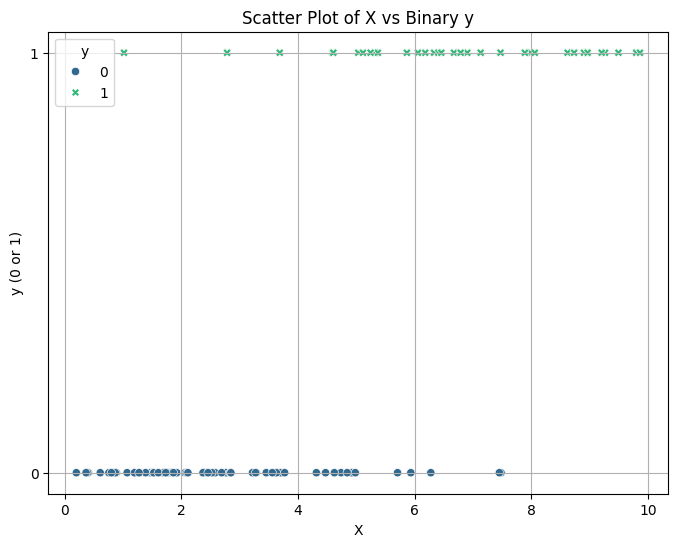

In [13]:
# Visualize the data
plt.figure(figsize=(8, 6))
sns.scatterplot(x='X', y='y', hue='y', data=df_log, palette='viridis', style='y', markers=['o', 'X'])
plt.title('Scatter Plot of X vs Binary y')
plt.xlabel('X')
plt.ylabel('y (0 or 1)')
plt.yticks([0, 1])
plt.grid(True)
plt.show()

3.  **Split the data:** Split the dataset into training (80%) and testing (20%) sets.


In [14]:
# Split the data
X_log_reshaped = df_log[['X']]
y_log_data = df_log['y']

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log_reshaped, y_log_data, test_size=0.2, random_state=42)

print(f"X_train_log shape: {X_train_log.shape}")
print(f"X_test_log shape: {X_test_log.shape}")
print(f"y_train_log shape: {y_train_log.shape}")
print(f"y_test_log shape: {y_test_log.shape}")

X_train_log shape: (80, 1)
X_test_log shape: (20, 1)
y_train_log shape: (80,)
y_test_log shape: (20,)


4.  **Train a Logistic Regression model:**
    *   Use `sklearn.linear_model.LogisticRegression` to train a model on the training data.
    *   Print the coefficients and intercept.


In [15]:
# Train a Logistic Regression model
from sklearn.linear_model import LogisticRegression

model_log = LogisticRegression(random_state=42)
model_log.fit(X_train_log, y_train_log)

# Print coefficients and intercept
print(f"Coefficient: {model_log.coef_[0][0]:.4f}")
print(f"Intercept: {model_log.intercept_[0]:.4f}")

Coefficient: 1.0401
Intercept: -5.5112


5.  **Evaluate the model:**
    *   Make predictions on the test set.
    *   Calculate and print the accuracy, precision, recall, and F1-score.
    *   Display the confusion matrix.


Accuracy: 0.8500
Precision: 0.8750
Recall: 0.7778
F1-score: 0.8235


<Figure size 600x600 with 0 Axes>

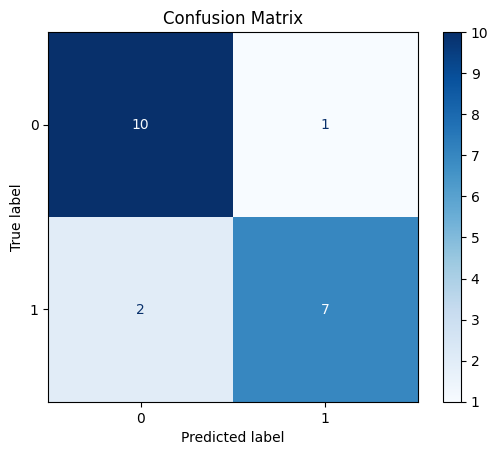

In [16]:
# Evaluate the model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

y_pred_log = model_log.predict(X_test_log)

accuracy = accuracy_score(y_test_log, y_pred_log)
precision = precision_score(y_test_log, y_pred_log)
recall = recall_score(y_test_log, y_pred_log)
f1 = f1_score(y_test_log, y_pred_log)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test_log, y_pred_log)
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

plt.figure(figsize=(6, 6))
display_cm.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

6.  **Plot the decision boundary:** Overlay the decision boundary on the scatter plot of `X` vs `y`.


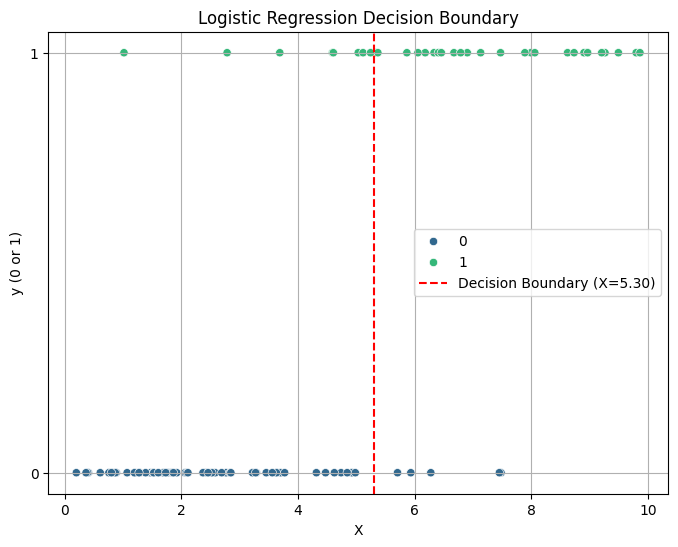

In [18]:
# Plot the decision boundary
plt.figure(figsize=(8, 6))
sns.scatterplot(x='X', y='y', hue='y', data=df_log, palette='viridis')

# Plot decision boundary
# The decision boundary is where P(y=1|X) = 0.5, which means log-odds = 0
# For Logistic Regression, log(p/(1-p)) = coef * X + intercept
# Setting log(p/(1-p)) = 0 gives coef * X + intercept = 0
# So, X = -intercept / coef

decision_boundary_x = -model_log.intercept_[0] / model_log.coef_[0][0]
plt.axvline(x=decision_boundary_x, color='red', linestyle='--', label=f'Decision Boundary (X={decision_boundary_x:.2f})')

plt.title('Logistic Regression Decision Boundary')
plt.xlabel('X')
plt.ylabel('y (0 or 1)')
plt.yticks([0, 1])
plt.grid(True)
plt.legend()
plt.show()